# Spectral response

The purpose of this script is to cross check the zero-points and magnitudes of the PLATO N-CAM, F-CAM blue, and F-CAM red response of PlatoSim versus that reported in PLATO-DLR-PL-TN-0113.

Creator: 2024-12-18 - Juan Cabrera 

Updated: 2025-01-07 - Nicholas Jannsen  

Last tested with PlatoSim version develop:
```
commit 7a3f254e05bc0fed4dce1c4c1c690f7e361717c1
Author: Nicholas Jannsen <nicholasemborgjannsen@gmail.com>
Date:   Tue Jan 7 10:29:45 2025 +0100
```

In [2]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# To interact with the plot use
%matplotlib notebook

In [3]:
import os
import scipy
from scipy import ndimage
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

---
## PlatoSim's wavelength dependent parameters
---

In [4]:
def estimate_quantity(dictionary, 
                      quantity, 
                      performance='Required', 
                      time='BOL', 
                      camera='all', 
                      plot=True):
    """Small function to quickly plot the QE and TE.
    
    This function takes as input a dictionary with a mandatory keyword ('wl') 
    and optional keyword which is built combining the parameters provided to the
    function, namely keyword = f'{quantity}_{performance}_{time}'.The function
    processes N-CAM and F-CAM blue and red using cutoffs that are taken from the
    requirements. Therefore, not identical to the as built filters. 
    
    The function will take the optional keyword (f'{quantity}_{performance}_{time}'),
    will make a spline interpolation, will integrate the area below the interpolated
    curve with a trapezoidal function from numpy, and return the area below the curve.
    The function returns a list with the area below the curve, but two of the values
    might be None depending on the value of the parameter 'camera':
        - If 'camera' is 'all', then the function returns the area below the curve
          (for the whole wavelength interval, for the blue interval, for the red interval).
        - If 'camera' is 'ncam', then the function returns the area 
          (for the whole wavelength interval, None, None).
        - If 'camera' is 'blue', then the function returns the area 
          (None, for the blue interval, None).
        - If 'camera' is 'red', then the function returns the area
        (None, None, for the red interval).
    """
    wl = dictionary['wl']
    xx = dictionary[f'{quantity}_{performance}_{time}']
    
    dex_nan = np.isnan(xx)
    wl = wl[~dex_nan]
    xx = xx[~dex_nan]
    
    grid_no = 500
    wl_int = np.linspace(wl[0], wl[-1], grid_no)                                                                                                                                         
    spline = scipy.interpolate.make_interp_spline(wl, xx, k=3)                                                                                                                                             
    xx_int = spline(wl_int)

    print(f'{quantity}: As {performance} {time}')
    
    dex_665 = ut.findNearestIndex(wl_int, 665)
    dex_700 = ut.findNearestIndex(wl_int, 700)
    
    if camera in ['all', 'ncam']:
        xx_NCAM = np.trapz(xx_int / (len(wl_int) - 1))
        print(f"N-CAM     : {xx_NCAM:.4f}")
    else: 
        xx_NCAM = None
        
    if camera in ['all', 'blue']:
        xx_FCAM_blue = np.trapz(xx_int[:dex_700] / (len(wl_int[:dex_700]) - 1))
        print(f"F-CAM blue: {xx_FCAM_blue:.4f}")
    else: 
        xx_FCAM_blue = None
        
    if camera in ['all', 'red']:
        xx_FCAM_red  = np.trapz(xx_int[dex_665:] / (len(wl_int[dex_665:]) - 1))
        print(f"F-CAM red : {xx_FCAM_red:.4f}")
    else: 
        xx_FCAM_red = None

    # Plot figure
    if plot:
        xlim = [450, 1050]
        fig = plt.figure(figsize=(8,6))
        plt.axvspan(xlim[0], wl[0],  facecolor='0.2', alpha=0.3)
        plt.axvspan(wl[-1], xlim[1], facecolor='0.2', alpha=0.3)
        if camera in ['all', 'ncam']:
            plt.axhline(y=xx_NCAM, color='g', linestyle=':', linewidth=2, label = "N-CAM")
        if camera in ['all', 'blue']:
            plt.fill_between(wl_int[:dex_700], xx_int[:dex_700], color='blue', alpha=.1)
            plt.axhline(y=xx_FCAM_blue, color='b', linestyle=':', linewidth=2, label = "F-CAM blue")
        if camera in ['all', 'red']:
            plt.fill_between(wl_int[dex_665:], xx_int[dex_665:], color='red',  alpha=.1)
            plt.axhline(y=xx_FCAM_red,  color='r', linestyle=':', linewidth=2, label = "F-CAM red")
        plt.plot(wl_int, xx_int, 'k--')
        plt.plot(wl, xx, 'ko')
        plt.title(f"As {performance} {time}")
        plt.xlabel("Wavelength [nm]")
        plt.ylabel(quantity)
        plt.xlim(xlim)
        if quantity == 'QE':
            plt.ylim(0, 1)
        elif quantity == 'TE':
            plt.ylim(pt.getAxesMinMax(y=xx_int, percentage=5))
        plt.tight_layout();

    return xx_NCAM, xx_FCAM_blue, xx_FCAM_red

---
## Transmission efficiency
---

This is the transmissivity of the optics. We further provide a calculation including the tranmissivity of the filters included below.

Notes:
- PlatoSim define the transmission efficiency as the `T_fil * T_op` from the PLATO-PL-DLR-TN-0113
- PlatoSim apply vignietting (defined as `CCD/RelativeTransmissivity`) across the FPA

In [5]:
# Prepare a table for PlatoSim's paramters
df = pd.DataFrame()

### Tabulated values from Anko Börner


* `optics_transmission_1.2pc_bol_cutoff_19-03-31.txt`

* `optics_transmission_1.2pc_eol_cutoff_19-03-31.txt`

These are values that were used by A. Börner to replicate the overall optical transmission requirements `PL-SYS-263` and `PL-SYS-5198`, which include:
- molecular contamination
- particulate contamination
- optical transmission of the lenses.

The values below are the optical transmission of the lenses that, when multiplied by particulate contamination, molecular contamination, and the cutoff filters of the N-CAMs, reproduce the values from the TRD (`PL-SYS-263` and `PL-SYS-5198`). Since 2023 at mission level we prefer to tabulate the values that can be directly used to measure the optical transmission, discouraging the multiplication of different factors.

In [6]:
TE = {'wl' : np.arange(500, 1050, 50),
      'TE_Required_BOL' : np.array([0.7651, 0.7972, 0.8048, 0.8107, 0.8183, 0.8243, 
                                    0.8284, 0.8301, 0.8319, 0.8327, 0.8344]),
      'TE_Required_EOL' : np.array([0.7379, 0.7719, 0.7835, 0.7918, 0.8018, 0.8076,
                                    0.8125, 0.8142, 0.8158, 0.8175, 0.8183])
     }

TE: As Required BOL
N-CAM     : 0.8182
F-CAM blue: 0.8020
F-CAM red : 0.8276


<IPython.core.display.Javascript object>


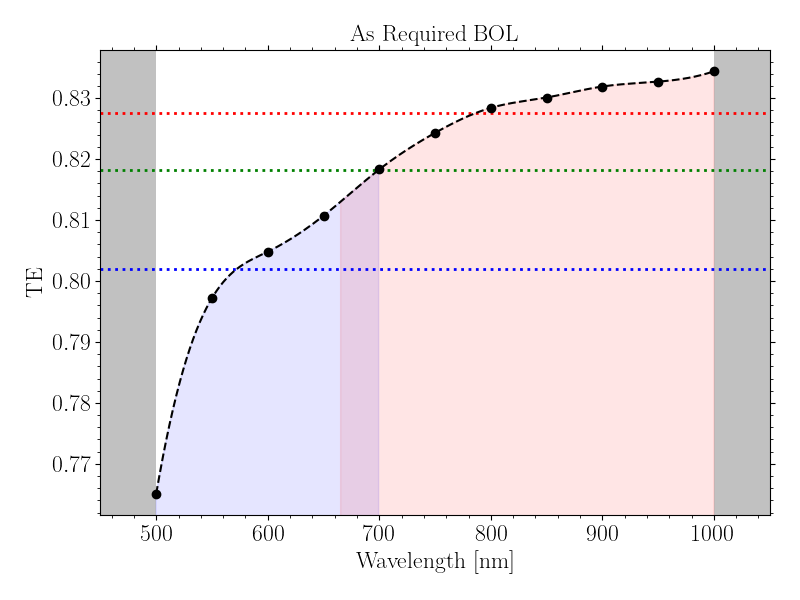

In [7]:
df['TE_Req_BOL_v1'] = estimate_quantity(TE, 'TE', 'Required', 'BOL')

TE: As Required EOL
N-CAM     : 0.7999
F-CAM blue: 0.7801
F-CAM red : 0.8115


<IPython.core.display.Javascript object>


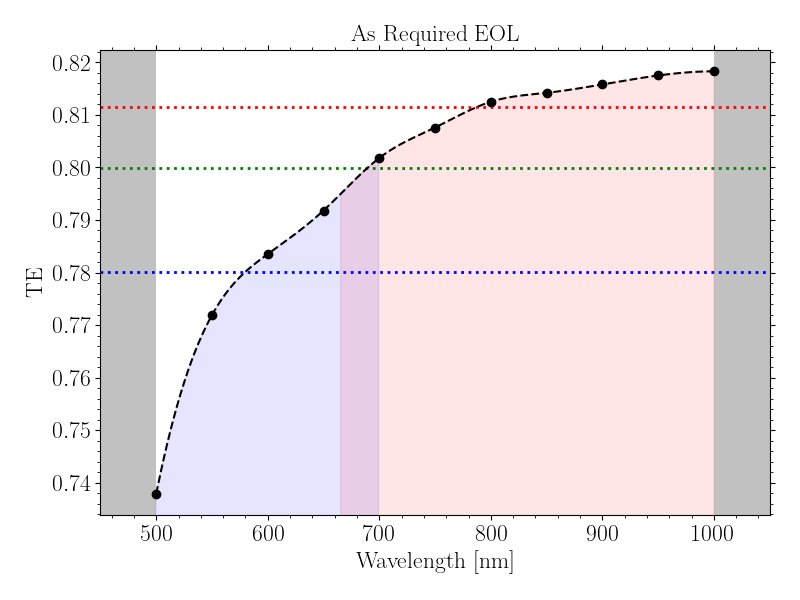

In [8]:
df['TE_Req_EOL_v1'] = estimate_quantity(TE, 'TE', 'Required', 'EOL')

### N-CAM tabulations from MPDB (frozen v.4)

- `optical_transmission_ncam_v2.csv`

Note that we cannot directly compare the values in the MPDB below with the values in Anko’s tables. The values in Anko’s tables would be comparable to the values in ‘optical transmission’(in absolute number, because the values in ‘optical transmission’ below are actually measured in the EM) or in ‘as designed TOU optical transmission’ (which are measured values for the PFM). 

However, the MPDB table shows measured values of the optical transmission from the TOU performance report (see details on the Instrument Performance Report, `PTO-EST-PL-REP-0952`). 

The values in the column `required bol transmission` and `required eol transmission` include optics and contamination.

In [86]:
# Add columns from latest MPDB 
df_ncam = pd.read_csv('optical_transmission_ncam_v2.csv', comment='#')
df_ncam

,wavelength,moc,pac,optical transmission,expected transmission,required bol transmission,required eol tranmission,as designed TOU optical transmission,as designed camera effective transmission
0,500,0.880,0.98,0.800,0.690,0.658,0.634,0.87,0.750
1,550,0.914,0.98,0.858,0.769,0.711,0.688,0.87,0.779
2,600,0.953,0.98,0.875,0.817,0.747,0.727,0.87,0.813
3,650,0.959,0.98,0.864,0.813,0.756,0.738,0.87,0.818
4,700,0.969,0.98,0.874,0.829,0.771,0.755,0.87,0.826
5,750,0.972,0.98,0.873,0.832,0.779,0.763,0.87,0.829
6,800,0.974,0.98,0.883,0.843,0.785,0.770,0.87,0.830
7,850,0.976,0.98,0.893,0.855,0.788,0.773,0.87,0.832
8,900,0.978,0.98,0.893,0.856,0.791,0.776,0.87,0.834
9,950,0.978,0.98,0.893,0.856,0.792,0.777,0.87,0.834


In [97]:
# Add pandas columns into dictonary and correct for moc and pac to get clean TE
contamination = df_ncam['moc'].to_numpy() * df_ncam['pac'].to_numpy()
TE_ncam = {'wl': df_ncam['wavelength'].to_numpy()}
TE_ncam['TE_Expected_BOL_v2'] = df_ncam['expected transmission'].to_numpy()     / contamination
TE_ncam['TE_Required_BOL_v2'] = df_ncam['required bol transmission'].to_numpy() / contamination
TE_ncam['TE_Required_EOL_v2'] = df_ncam['required eol tranmission'].to_numpy()  / contamination

Note also that even if F-CAM blue and red values are computed below, these ignore the filters, so they are to be handled with care.

In [91]:
TE_Des_v2 = df_ncam['as designed TOU optical transmission'].to_numpy().mean()
df['TE_Des_v2'] = TE_Des_v2, TE_Des_v2, TE_Des_v2
df['TE_Des_v2']

0    0.87
1    0.87
2    0.87
Name: TE_Des_v2, dtype: float64

TE: As Expected BOL_v2
N-CAM     : 0.8755
F-CAM blue: 0.8602
F-CAM red : 0.8840


<IPython.core.display.Javascript object>


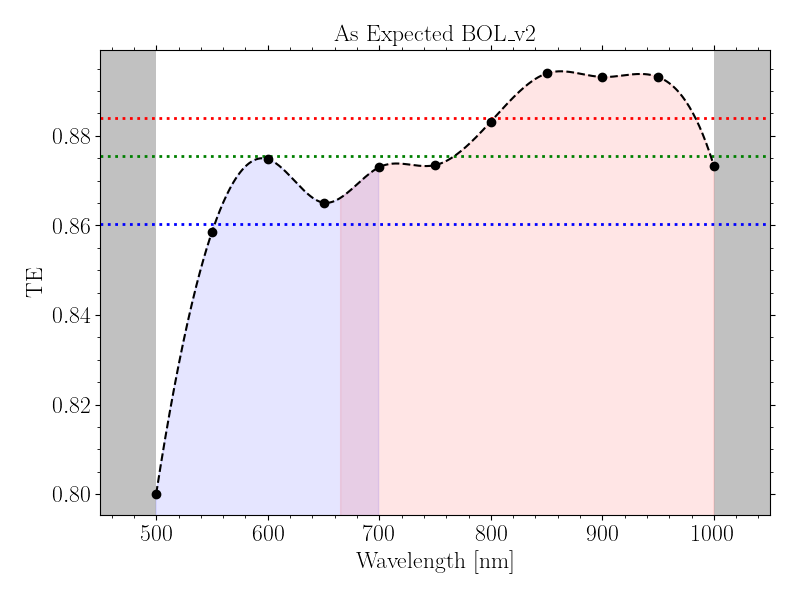

In [92]:
# TE from measurements of EM model
df['TE_Exp_v2'] = estimate_quantity(TE_ncam, 'TE', 'Expected', 'BOL_v2')

TE: As Required BOL_v2
N-CAM     : 0.8125
F-CAM blue: 0.7973
F-CAM red : 0.8213


<IPython.core.display.Javascript object>


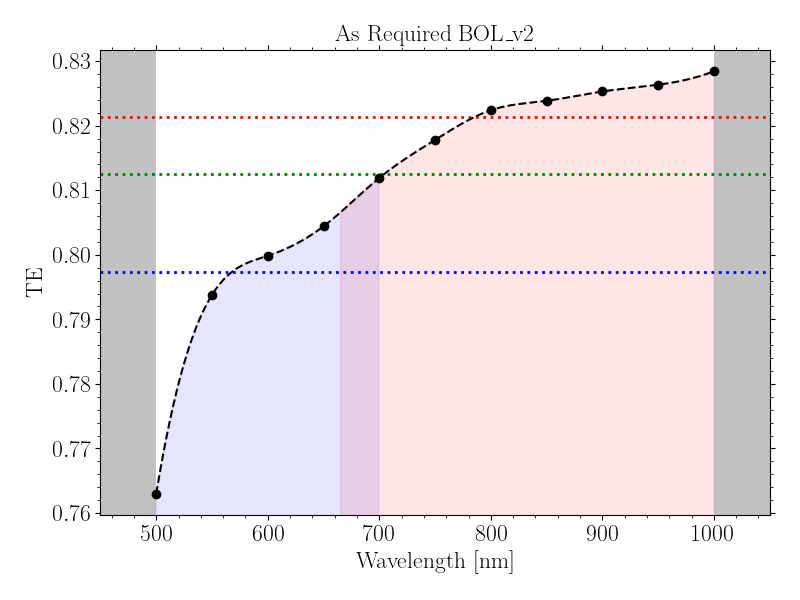

In [98]:
df['TE_Req_BOL_v2'] = estimate_quantity(TE_ncam, 'TE', 'Required', 'BOL_v2')

TE: As Required EOL_v2
N-CAM     : 0.7941
F-CAM blue: 0.7751
F-CAM red : 0.8051


<IPython.core.display.Javascript object>


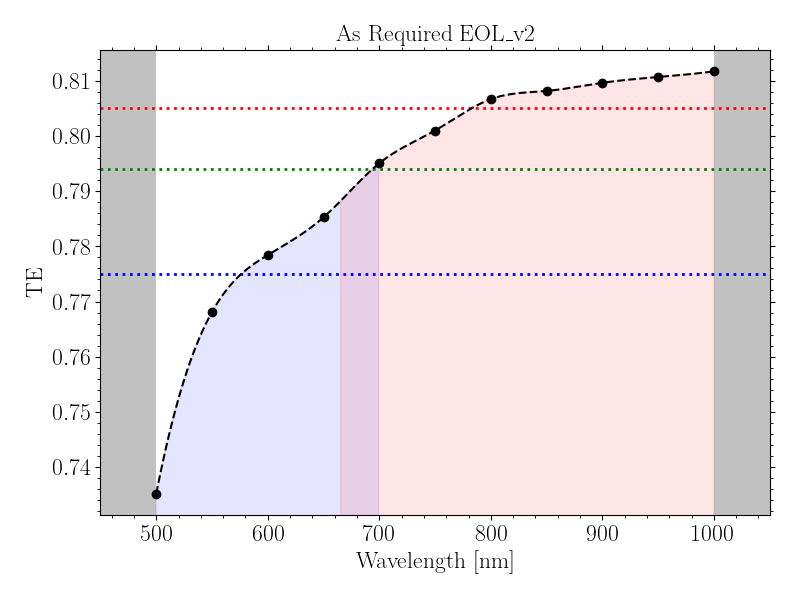

In [94]:
df['TE_Req_EOL_v2'] = estimate_quantity(TE_ncam, 'TE', 'Required', 'EOL_v2')

### F-CAM tabulations from MPDB (frozen v.4)

- `optical_transmission_fcam_v2.csv`

In [57]:
# Load F-CAM parameters from file provided by Juan
df_fcam = pd.read_csv('optical_transmission_fcam_v2.csv', comment='#', sep=';')
df_fcam.drop(df_fcam.tail(1).index, inplace=True)
df_fcam

,Wavelength,Blue filter low limit,Blue filter mission,Red filter low,Red filter mission,moc,pac,optical transmission,as designed TOU optical transmission,required transmission blue BOL,required transmission blue EOL,required transmission red BOL,required transmission red EOL,expected transmission blue camera,expected transmission red camera,as designed blue camera effective transmission,as designed red camera effective transmission,
0,500.0,0.00,0.986,0.00,0.000,0.880,0.98,0.800,0.87,NaN,NaN,NaN,NaN,0.000,0.000,0.740,0.000,NaN
1,505.0,0.00,0.986,0.00,0.000,0.883,0.98,0.806,0.87,0.559,0.543,NaN,NaN,0.000,0.000,0.743,0.000,NaN
2,525.0,0.73,0.986,0.00,0.000,0.897,0.98,0.829,0.87,0.582,0.562,NaN,NaN,0.532,0.000,0.754,0.000,NaN
3,550.0,0.85,0.986,0.00,0.000,0.914,0.98,0.858,0.87,0.604,0.585,NaN,NaN,0.653,0.000,0.768,0.000,NaN
4,575.0,0.85,0.986,0.00,0.000,0.933,0.98,0.866,0.87,0.620,0.601,NaN,NaN,0.674,0.000,0.785,0.000,NaN
5,600.0,0.85,0.986,0.00,0.000,0.953,0.98,0.875,0.87,0.635,0.618,NaN,NaN,0.695,0.000,0.801,0.000,NaN
6,625.0,0.85,0.986,0.00,0.000,0.956,0.98,0.870,0.87,0.639,0.623,NaN,NaN,0.692,0.000,0.804,0.000,NaN
7,650.0,0.85,0.986,0.00,0.000,0.959,0.98,0.864,0.87,0.643,0.628,NaN,NaN,0.690,0.000,0.806,0.000,NaN
8,665.0,0.85,0.986,0.00,0.989,0.962,0.98,0.867,0.87,NaN,NaN,0.647,0.632,0.695,0.000,0.809,0.811,NaN
9,700.0,0.00,0.000,0.85,0.989,0.969,0.98,0.874,0.87,0.655,0.642,0.655,0.642,0.000,0.705,0.000,0.817,NaN


In [68]:
# Add columns from latest MPDB to new dictionary
dex = 9
contamination = df_fcam['moc'].to_numpy()[:dex] * df_fcam['pac'].to_numpy()[:dex]
TE_blue = {'wl': df_fcam['Wavelength'].to_numpy()[:dex]}
TE_blue['TE_Expected_BOL_v2_blue'] = df_fcam['expected transmission blue camera'].to_numpy()[:dex] / contamination
TE_blue['TE_Required_BOL_v2_blue'] = df_fcam['required transmission blue BOL'].to_numpy()[:dex] / contamination
TE_blue['TE_Required_EOL_v2_blue'] = df_fcam['required transmission blue EOL'].to_numpy()[:dex] / contamination

dex = 8
contamination = df_fcam['moc'].to_numpy()[dex:] * df_fcam['pac'].to_numpy()[dex:]
TE_red = {'wl': df_fcam['Wavelength'].to_numpy()[dex:]}
TE_red['TE_Expected_BOL_v2_red'] = df_fcam['expected transmission red camera'].to_numpy()[dex:] / contamination
TE_red['TE_Required_BOL_v2_red'] = df_fcam['required transmission red BOL'].to_numpy()[dex:] / contamination
TE_red['TE_Required_EOL_v2_red'] = df_fcam['required transmission red EOL'].to_numpy()[dex:] / contamination

In [70]:
df['TE_Des_v2'] = 0.87, 0.87 * 0.986, 0.87 * 0.989
df['TE_Des_v2']

0    0.87000
1    0.85782
2    0.86043
Name: TE_Des_v2, dtype: float64

TE: As Expected BOL_v2_blue
F-CAM blue: 0.6566


<IPython.core.display.Javascript object>


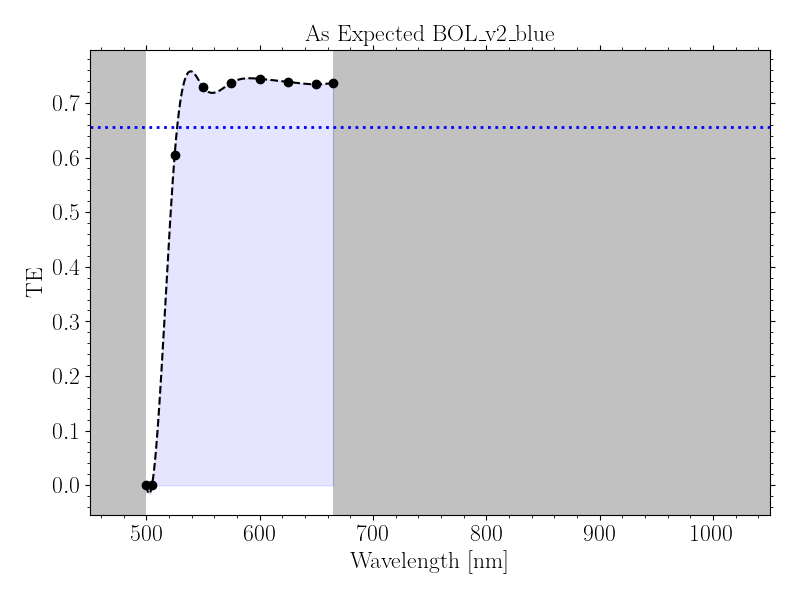

In [71]:
df['TE_Exp_v2'].iloc[1] = estimate_quantity(TE_blue, 'TE', 'Expected', 'BOL_v2_blue', camera='blue')[1]

TE: As Required BOL_v2_blue
F-CAM blue: 0.6745


<IPython.core.display.Javascript object>


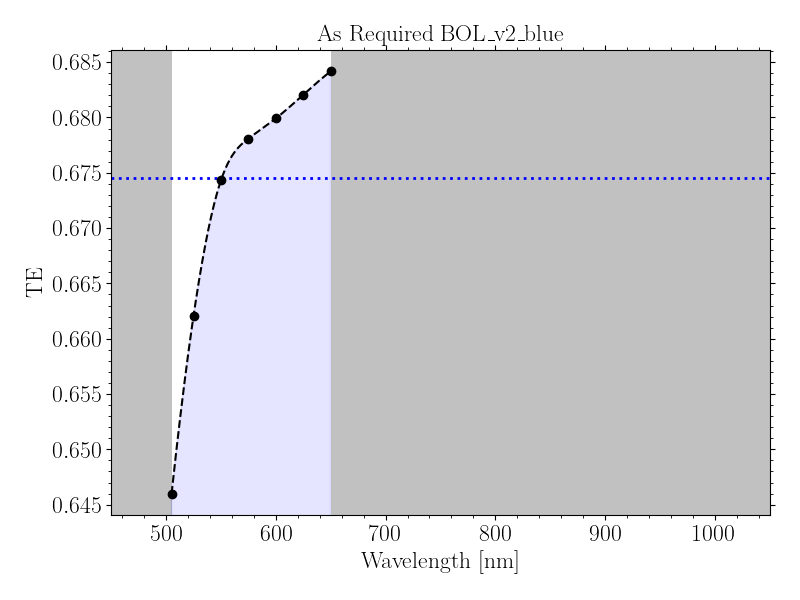

In [72]:
df['TE_Req_BOL_v2'].iloc[1] = estimate_quantity(TE_blue, 'TE', 'Required', 'BOL_v2_blue', camera='blue')[1]

TE: As Required EOL_v2_blue
F-CAM blue: 0.6549


<IPython.core.display.Javascript object>


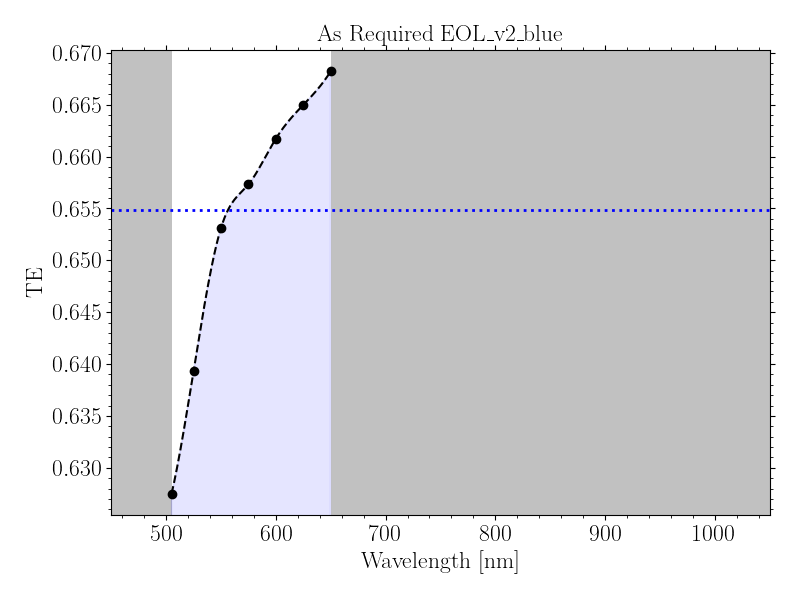

In [73]:
df['TE_Req_EOL_v2'].iloc[1] = estimate_quantity(TE_blue, 'TE', 'Required', 'EOL_v2_blue', camera='blue')[1]

TE: As Expected BOL_v2_red
F-CAM red : 0.7266


<IPython.core.display.Javascript object>


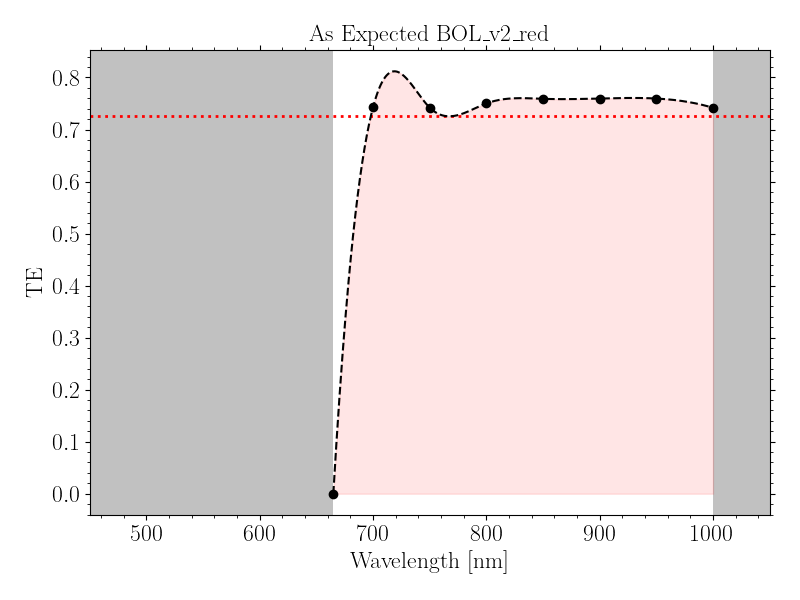

In [74]:
df['TE_Exp_v2'].iloc[2] = estimate_quantity(TE_red, 'TE', 'Expected', 'BOL_v2_red', camera='red')[2]

TE: As Required BOL_v2_red
F-CAM red : 0.6980


<IPython.core.display.Javascript object>


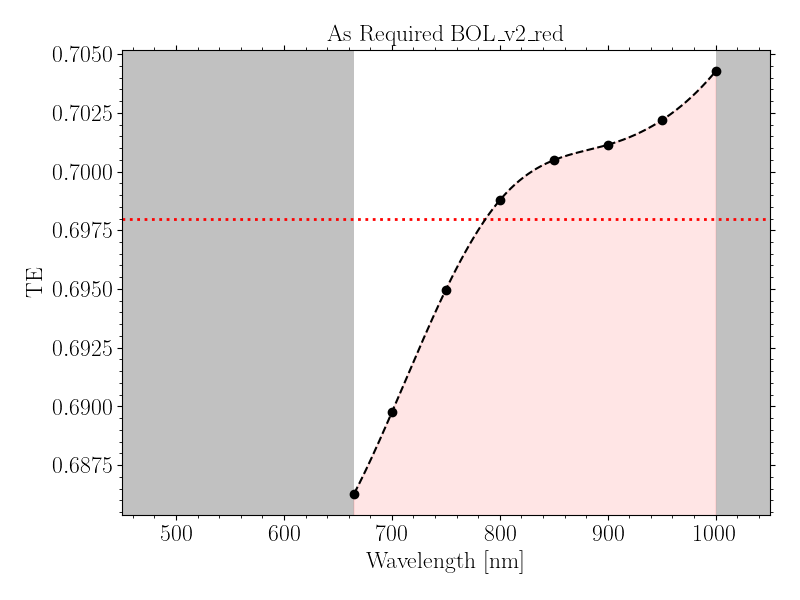

In [75]:
df['TE_Req_BOL_v2'].iloc[2] = estimate_quantity(TE_red, 'TE', 'Required', 'BOL_v2_red', camera='red')[2]

TE: As Required EOL_v2_red
F-CAM red : 0.6845


<IPython.core.display.Javascript object>


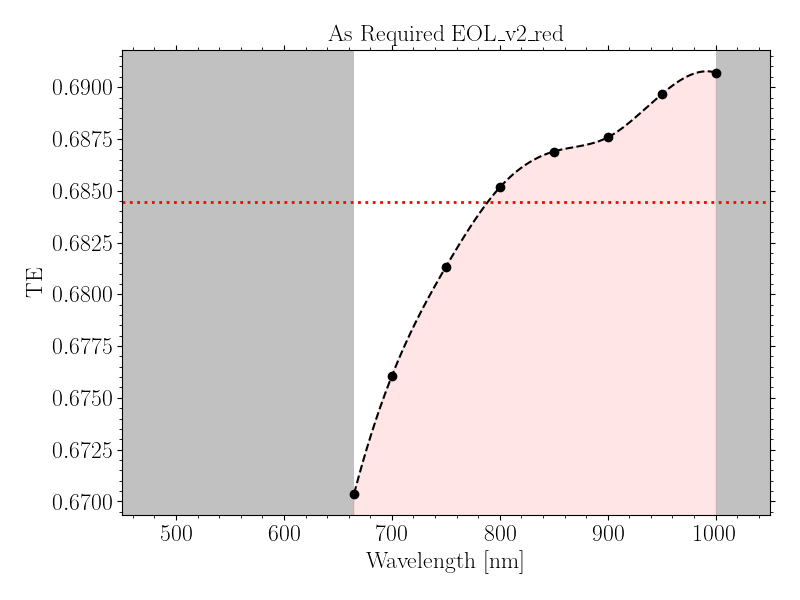

In [76]:
df['TE_Req_EOL_v2'].iloc[2] = estimate_quantity(TE_red, 'TE', 'Required', 'EOL_v2_red', camera='red')[2]

### TE result comparison

In [77]:
# Show data frame with tabulated values calculated above
df

,TE_Req_BOL_v1,TE_Req_EOL_v1,TE_Exp_v2,TE_Req_BOL_v2,TE_Eng_v2,TE_Req_EOL_v2,TE_Des_v2
0,0.818234,0.799907,0.875484,0.812541,0.875225,0.794064,0.87000
1,0.802017,0.780122,0.656630,0.674514,0.859929,0.654860,0.85782
2,0.827633,0.811549,0.726647,0.697963,0.883803,0.684477,0.86043


#### Check TE (without contamination)

In [78]:
def compute_te_comparison(sim, camera, col):
    lx = 35
    print(f'PlatoSim {camera} config parameters')
    print('-'*lx)
    print('- TE BOL :', sim["Telescope/TransmissionEfficiency/BOL"])
    print('- TE EOL :', sim["Telescope/TransmissionEfficiency/EOL"])
    # Compute the N-CAM "As Required BOL" modulae
    print('\nTE "As Required BOL": v1 - v2')
    print('-'*lx)
    print(df['TE_Req_BOL_v1'][col] - df['TE_Req_BOL_v2'][col])
    print('\nTE "As Required EOL": v1 - v2')
    print('-'*lx)
    print(df['TE_Req_EOL_v1'][col] - df['TE_Req_EOL_v2'][col])
    print('\nTE "As Required BOL": PlatoSim - v2')
    print('-'*lx)
    print(sim["Telescope/TransmissionEfficiency/BOL"] - df['TE_Req_BOL_v2'][col])
    print('\nTE "As Required EOL": PlatoSim - v2')
    print('-'*lx)
    print(sim["Telescope/TransmissionEfficiency/EOL"] - df['TE_Req_EOL_v2'][col])

In [79]:
# Check N-CAM YAML parameters
sim = Simulation('test')
sim.useNormalCamera(performance='required')
compute_te_comparison(sim, 'N-CAM', col=0)

PlatoSim N-CAM config parameters
-----------------------------------
- TE BOL : 0.8135
- TE EOL : 0.7945

TE "As Required BOL": v1 - v2
-----------------------------------
0.005693727112400571

TE "As Required EOL": v1 - v2
-----------------------------------
0.00584347072209257

TE "As Required BOL": PlatoSim - v2
-----------------------------------
0.0009593766924879121

TE "As Required EOL": PlatoSim - v2
-----------------------------------
0.0004364341089498902


In [80]:
# Check F-CAM blue YAML parameters
sim = Simulation('test')
sim.useFastCamera(passband='blue', performance='required')
compute_te_comparison(sim, 'F-CAM blue', col=1)

PlatoSim F-CAM blue config parameters
-----------------------------------
- TE BOL : 0.7899
- TE EOL : 0.7684

TE "As Required BOL": v1 - v2
-----------------------------------
0.12750296546685957

TE "As Required EOL": v1 - v2
-----------------------------------
0.12526141375690059

TE "As Required BOL": PlatoSim - v2
-----------------------------------
0.11538572810045955

TE "As Required EOL": PlatoSim - v2
-----------------------------------
0.1135398217921415


In [81]:
# Check F-CAM red YAML parameters
sim = Simulation('test')
sim.useFastCamera(passband='red', performance='required')
compute_te_comparison(sim, 'F-CAM red', col=2)

PlatoSim F-CAM red config parameters
-----------------------------------
- TE BOL : 0.8198
- TE EOL : 0.804

TE "As Required BOL": v1 - v2
-----------------------------------
0.12966964231662215

TE "As Required EOL": v1 - v2
-----------------------------------
0.12707151008935802

TE "As Required BOL": PlatoSim - v2
-----------------------------------
0.1218366696015375

TE "As Required EOL": PlatoSim - v2
-----------------------------------
0.11952299067874139


#### Check contamination

In [28]:
def show_yaml_response(sim):
    print('- Par. contamination : ', sim["CCD/Contamination/ParticulateContaminationEfficiency"])
    print('- Mol. contamination : ', sim["CCD/Contamination/MolecularContaminationEfficiency"])
    print('- CCD polarization   : ', sim["CCD/Polarization/ExpectedValue"])
    print('- CCD QE             : ', sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"])

In [29]:
# As simulated transmission values for F-CAMs
TE_fil_FCAM_blue = 0.986
TE_fil_FCAM_red  = 0.989

# Print blue and red filter values used in PlatoSim
print('BOL', df['TE_Req_BOL_v2'][1] * TE_fil_FCAM_blue, df['TE_Req_BOL_v2'][2] * TE_fil_FCAM_red)
print('EOL', df['TE_Req_EOL_v2'][1] * TE_fil_FCAM_blue, df['TE_Req_EOL_v2'][2] * TE_fil_FCAM_red)

BOL 0.606595369825646 0.6591437584844101
EOL 0.5889703692121797 0.6464096383848735


CONCLUSIONS:
- TE N-CAM "As Required": BOL and EOL between (v1 and v2) or (PlatoSim and v2) are almost identical for the N-CAM estimates. 
- TE F-CAM blue "As Required": There is a disagreement for both BOL and EOL.
- TE F-CAM red  "As Required": There is a disagreement for both BOL and EOL.

## Quantum efficiency

The Quantum Efficiency (QE) is the same for all CCDs, i.e. independent of:
- camera (N-CAM and F-CAM)
- time (BOL and EOL)


### QE tabulations from the MPDB (frozen v.4) 


In [30]:
# Interpolate data with cubic spline
QE = {'wl' : np.array([500, 600, 700, 800, 900, 950, 1000]),
      'QE_Required_BOL'  : np.array([0.737, 0.877, 0.858, 0.655, 0.314, 0.165, 0.062]),
      'QE_Designed_BOL'  : np.array([0.826, 0.923, 0.873, 0.664, 0.335, 0.188, 0.082]),
     }

QE: As Required BOL
N-CAM     : 0.6267
F-CAM blue: 0.8505
F-CAM red : 0.5184


<IPython.core.display.Javascript object>


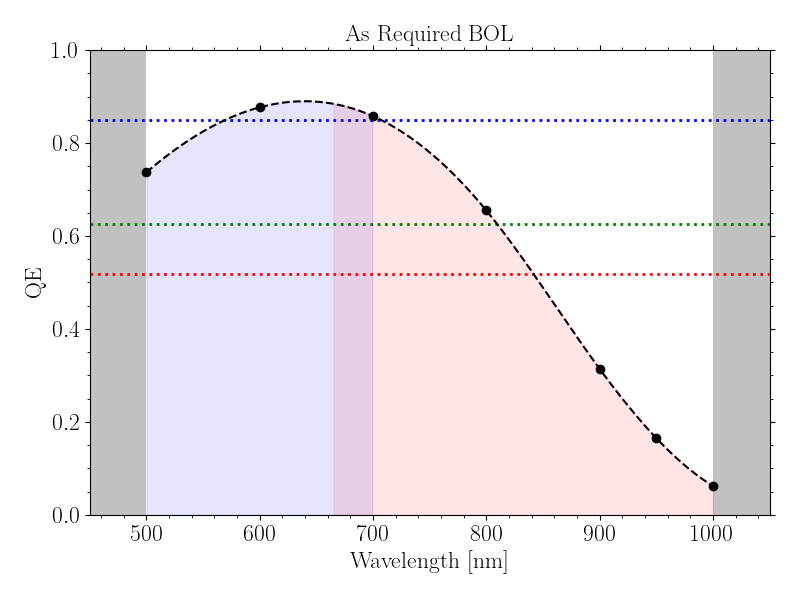

In [31]:
QE_Required_BOL = estimate_quantity(QE, 'QE', 'Required', 'BOL')

QE: As Designed BOL
N-CAM     : 0.6552
F-CAM blue: 0.8986
F-CAM red : 0.5344


<IPython.core.display.Javascript object>


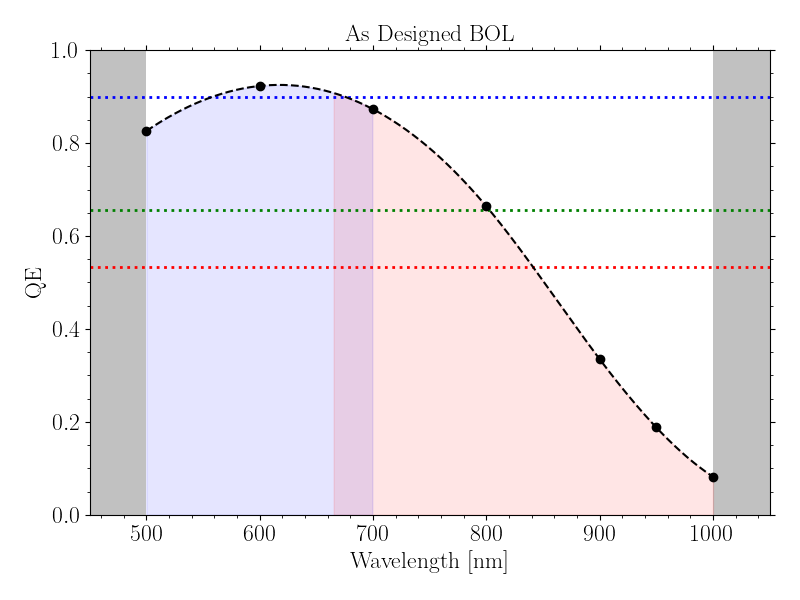

In [32]:
QE_Designed_BOL = estimate_quantity(QE, 'QE', 'Designed', 'BOL')

## Absolute spectral response

We here look at the absolute spectral response for the "As Required" tabulated values.

In [33]:
def estimate_response(dictionary, quantity, performance='Required', time='BOL'):

    """Function integrate input data.
    """
    
    # Select columns
    wl = dictionary['wl']
    xx = dictionary[f'{quantity}_{performance}_{time}']
    
    # Remove NaN rows
    dex_nan = np.isnan(xx)
    wl = wl[~dex_nan]
    xx = xx[~dex_nan]
    
    # Interpolate data
    grid_no = 500
    wl_int = np.linspace(wl[0], wl[-1], grid_no)                                                                                                                                         
    spline = scipy.interpolate.make_interp_spline(wl, xx, k=3)                                                                                                                                             
    xx_int = spline(wl_int)
    
    return wl_int, xx_int


    
def estimate_absolute_response(wl_int, xx_int, performance='Required', time='BOL', 
                               camera='all', plot=True):
    
    """Function to compute and plot the absolute spectral response.
    """
    
    print(f'Spectral response "As {performance} {time}"')
    
    # Find wavelenght averages
    dex_665 = ut.findNearestIndex(wl_int, 665)
    dex_700 = ut.findNearestIndex(wl_int, 700)
    
    if camera in ['all', 'ncam']:
        xx_NCAM = np.trapz(xx_int / (len(wl_int) - 1))
        print(f"N-CAM      : {xx_NCAM:.4f}")
    else: 
        xx_NCAM = None
        
    if camera in ['all', 'blue']:
        xx_FCAM_blue = np.trapz(xx_int[:dex_700] / (len(wl_int[:dex_700]) - 1))
        print(f"F-CAM blue : {xx_FCAM_blue:.4f}")
    else: 
        xx_FCAM_blue = None
        
    if camera in ['all', 'red']:
        xx_FCAM_red  = np.trapz(xx_int[dex_665:] / (len(wl_int[dex_665:]) - 1))
        print(f"F-CAM red  : {xx_FCAM_red:.4f}")
    else: 
        xx_FCAM_red = None

    # Plot figure
    if plot:
        xlim = [450, 1050]
        fig = plt.figure(figsize=(8,6))
        plt.axvspan(xlim[0], wl[0],  facecolor='0.2', alpha=0.3)
        plt.axvspan(wl[-1], xlim[1], facecolor='0.2', alpha=0.3)
        if camera in ['all', 'ncam']:
            plt.axhline(y=xx_NCAM, color='g', linestyle=':', linewidth=2, label = "N-CAM")
        if camera in ['all', 'blue']:
            plt.fill_between(wl_int[:dex_700], xx_int[:dex_700], color='blue', alpha=.1)
            plt.axhline(y=xx_FCAM_blue, color='b', linestyle=':', linewidth=2, label = "F-CAM blue")
        if camera in ['all', 'red']:
            plt.fill_between(wl_int[dex_665:], xx_int[dex_665:], color='red',  alpha=.1)
            plt.axhline(y=xx_FCAM_red,  color='r', linestyle=':', linewidth=2, label = "F-CAM red")
        plt.plot(wl_int, xx_int, 'k--')
        plt.title(f"As {performance} {time}")
        plt.xlabel("Wavelength [nm]")
        plt.ylabel("Absolute spectral response")
        plt.xlim(xlim)
        plt.ylim(0, 1)
        plt.tight_layout();

    return xx_NCAM, xx_FCAM_blue, xx_FCAM_red

Spectral response "As Designed BOL"
N-CAM      : 0.5701
F-CAM blue : 0.7818
F-CAM red  : 0.4649


<IPython.core.display.Javascript object>


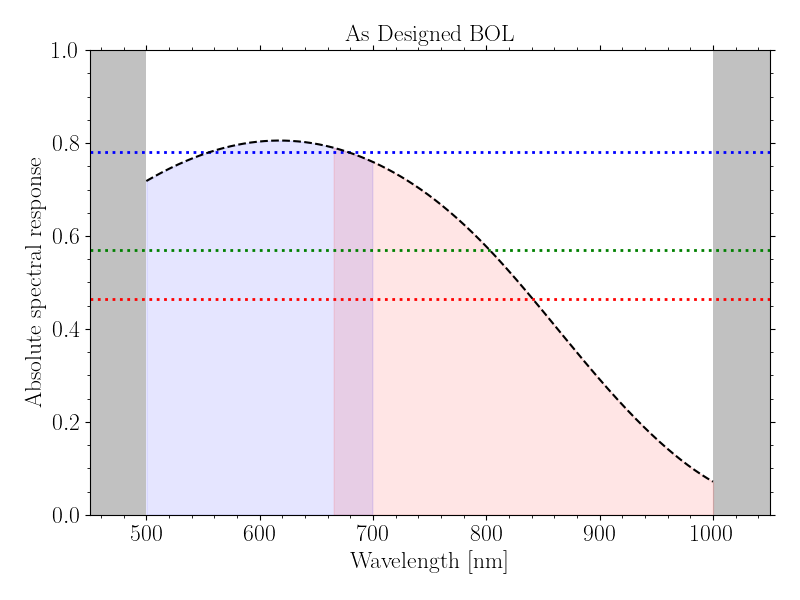

In [34]:
# Calculate the Absolute Spectral Response (ASR) "As Designed BOL"
te = estimate_response(TE_ncam, 'TE', 'Designed', 'BOL_v2')
qe = estimate_response(QE, 'QE', 'Designed', 'BOL')
wl = qe[0]
ASR = te[1] * qe[1]
estimate_absolute_response(wl, ASR, 'Designed', 'BOL');

Spectral response "As Required BOL"
N-CAM      : 0.4944
F-CAM blue : 0.6597
F-CAM red  : 0.4159


<IPython.core.display.Javascript object>


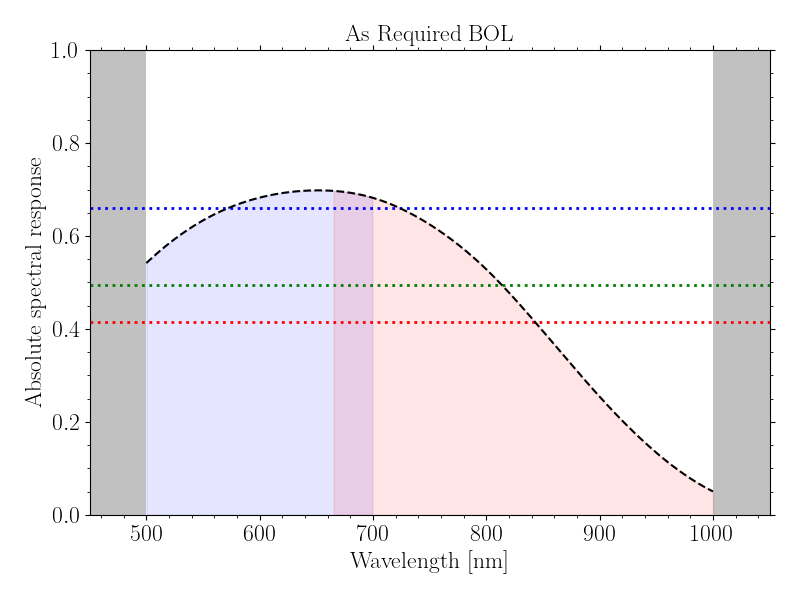

In [35]:
# Calculate the Absolute Spectral Response (ASR) "As Required BOL"
te = estimate_response(TE_ncam, 'TE', 'Required', 'EOL_v2')
qe = estimate_response(QE, 'QE', 'Required', 'BOL')
wl = qe[0]
ASR = te[1] * qe[1]
estimate_absolute_response(wl, ASR, 'Required', 'BOL');

### Compare with PlatoSim YAML parameters

In [36]:
def compute_response(sim):
    lx = 40
    trans = (sim["CCD/Contamination/ParticulateContaminationEfficiency"] *
             sim["CCD/Contamination/MolecularContaminationEfficiency"] *
             sim["CCD/Polarization/ExpectedValue"] * 
             sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"])
    total_BOL = sim["Telescope/TransmissionEfficiency/BOL"] * trans
    total_EOL = sim["Telescope/TransmissionEfficiency/EOL"] * trans
    
    print('Absolute spectral response')
    print('-'*lx)
    print('- TE BOL             : ', sim["Telescope/TransmissionEfficiency/BOL"])
    print('- TE EOL             : ', sim["Telescope/TransmissionEfficiency/EOL"])
    print('- Par. contamination : ', sim["CCD/Contamination/ParticulateContaminationEfficiency"])
    print('- Mol. contamination : ', sim["CCD/Contamination/MolecularContaminationEfficiency"])
    print('- CCD polarization   : ', sim["CCD/Polarization/ExpectedValue"])
    print('- CCD QE             : ', sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"])
    print('-'*lx)
    print(f'Absolute spectral response BOL : {total_BOL:.4f}')
    print(f'Absolute spectral response EOL : {total_EOL:.4f}')

In [37]:
# N-CAM spectral response at BOL (without vignetting)
sim = Simulation('test')
sim.useNormalCamera(performance='required')
compute_response(sim)

Absolute spectral response
----------------------------------------
- TE BOL             :  0.8135
- TE EOL             :  0.7945
- Par. contamination :  0.972
- Mol. contamination :  0.9573
- CCD polarization   :  0.989
- CCD QE             :  0.6218
----------------------------------------
Absolute spectral response BOL : 0.4655
Absolute spectral response EOL : 0.4546


In [38]:
# F-CAM blue spectral response (without vignetting)
sim = Simulation('test')
sim.useFastCamera(passband='blue', performance='required')
compute_response(sim)

Absolute spectral response
----------------------------------------
- TE BOL             :  0.7899
- TE EOL             :  0.7684
- Par. contamination :  0.972
- Mol. contamination :  0.9573
- CCD polarization   :  0.989
- CCD QE             :  0.7315
----------------------------------------
Absolute spectral response BOL : 0.5317
Absolute spectral response EOL : 0.5173


In [39]:
# F-CAM red spectral response (without vignetting)
sim = Simulation('test')
sim.useFastCamera(passband='red', performance='required')
compute_response(sim)

Absolute spectral response
----------------------------------------
- TE BOL             :  0.8198
- TE EOL             :  0.804
- Par. contamination :  0.972
- Mol. contamination :  0.9573
- CCD polarization   :  0.989
- CCD QE             :  0.4923
----------------------------------------
Absolute spectral response BOL : 0.3714
Absolute spectral response EOL : 0.3642


---
## Transmissivity
---

In [88]:
path = '/lhome/nicholas/software/workdir/DLR108'
f = SimFile(f'{path}/test_data/Ncam1.1_Q1_ccd1.hdf5')

In [89]:
# Fetch image map
im = f.getImage(0)
im_norm = ut.imageNorm(im, "log", sigma=0.5)
# Fetch throughput map
tm = f.getThroughputMap(0)
tm = ndimage.rotate(tm, -90)

<IPython.core.display.Javascript object>


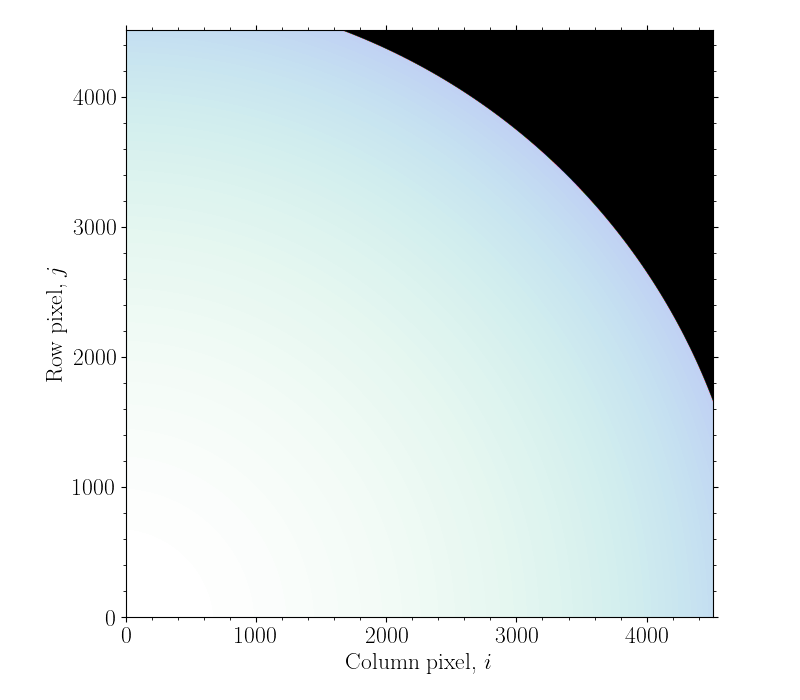

In [90]:
fig, ax = plt.subplots(1, 1, figsize=(8,7))
ax.imshow(tm, norm=None, cmap='cubehelix', origin='lower')
ax.set_xlabel(r'Column pixel, $i$')
ax.set_ylabel(r'Row pixel, $j$')
plt.tight_layout();

<IPython.core.display.Javascript object>


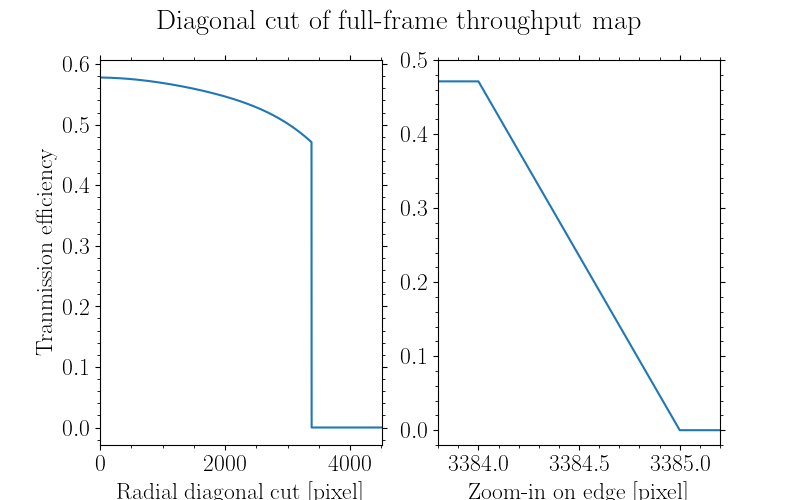

In [91]:
fig, ax = plt.subplots(1, 2, figsize=(8,5))

y = np.diag(tm)
x = np.arange(len(y))
ax[0].plot(x, y)
ax[0].set_xlim(min(x), max(x))
ax[0].set_ylabel('Tranmission efficiency')
ax[0].set_xlabel('Radial diagonal cut [pixel]')
#
ax[1].plot(x, y)
ax[1].set_xlim(3383.8, 3385.2)
ax[1].set_ylim(-0.02, 0.5)
ax[1].set_xlabel('Zoom-in on edge [pixel]')

fig.suptitle('Diagonal cut of full-frame throughput map')
fig.savefig('optical_vignetting.png', bbox_inches='tight', dpi=200)

---
## Test zero point fluxes
---

In [40]:
# Working directory 
workDir = Path('/lhome/nicholas/software/workdir/help_juan')

# The configurations
inputFile = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/inputfile.yaml'

# performance for the simulations
performance = 'required'

In [41]:
# The PLATO magnitudes (Pmag) and corresponding fluxes are taken from PLATO-DLR-PL-TN-0113
cfgs = [{'cam'        : 'N-CAM' , 
         'cfg_file'   : 'inputfile_ncam.yaml',
         'output_dir' : workDir / 'ncam',
         'Vmag'       : np.array([8, 9, 10, 11, 12, 13]),
         'Pmag'       : np.array([7.62, 8.62, 9.62, 10.62, 11.62, 12.62]),
         'flux_simulate_BOL' : np.array([1.84e5, 7.31e4, 2.91e4, 1.16e4, 4.62e3, 1.84e3]),
         'flux_required_BOL' : np.array([1.62e5, 6.44e4, 2.56e4, 1.02e4, 4.06e3, 1.62e3]),
         'flux_required_EOL' : np.array([1.58e5, 6.27e4, 2.50e4, 9.94e4, 3.96e3, 1.58e3]),
        },
        {'cam'        : 'F-CAMb', 
         'cfg_file'   : 'inputfile_fcamb.yaml',
         'output_dir' : workDir / 'fcamb',
         'Vmag'       : np.array([8, 9, 10, 11, 12, 13]),
         'Pmag'       : np.array( [ 7.88, 8.88, 9.88, 10.88, 11.88, 12.88]),
         'flux_simulate_BOL' : np.array([8.38e4, 3.33e4, 1.33e4, 5.28e3, 2.10e3, 8.38e2]),
         'flux_required_BOL' : np.array([6.58e4, 2.62e4, 1.04e4, 4.15e3, 1.65e3, 6.58e2]),
         'flux_required_EOL' : np.array([6.39e4, 2.54e4, 1.01e4, 4.03e3, 1.61e3, 6.39e2]),
        },
        {'cam'        : 'F-CAMr', 
         'cfg_file'   : 'inputfile_fcamr.yaml', 
         'output_dir' : workDir / 'fcamr',
         'Vmag'       : np.array([8, 9, 10, 11, 12, 13]),
         'Pmag'       : np.array( [ 7.40, 8.40, 9.40, 10.40, 11.40, 12.40]),
         'flux_simulate_BOL' : np.array([9.17e4, 3.65e4, 1.45e4, 5.78e3, 2.30e3, 9.17e2]),
         'flux_required_BOL' : np.array([7.41e4, 2.95e4, 1.17e4, 4.68e3, 1.86e3, 7.41e2]),
         'flux_required_EOL' : np.array([7.27e4, 2.89e4, 1.15e4, 4.58e3, 1.83e3, 7.27e2]),
         }]

In [42]:
# Here we generate baseline configuration files using the tools implemented by PlatoSim
for cfg in cfgs:
    
    # we will output the yaml configuration file here
    cfg_file = cfg['output_dir'] / cfg['cfg_file']
    
    # Create output directory for each sim
    if not os.path.isdir(cfg['output_dir']):
        os.mkdir(cfg['output_dir'])
    path = cfg['output_dir']
        
    # we call PlatoSim
    cfg['psim'] = Simulation(cfg['cam'])
    
    # We adjust the reference flux to that of the PLATO passband
    cfg['psim']['ObservingParameters/Fluxm0'] = 0.73244782244e8
    
    # We generate the default configurations
    if cfg['cam'] == 'N-CAM':
        cfg['psim'].useNormalCamera(performance=performance)
    elif cfg['cam'] == 'F-CAMb':
        cfg['psim'].useFastCamera(passband='blue', performance=performance)
    elif cfg['cam'] == 'F-CAMr':
        cfg['psim'].useFastCamera(passband='red', performance=performance)
    else:
        print('### error configuring camera ###')
        break
    
    # we output the default configurations to the yaml files
    cfg['psim'].writeYamlConfigurationFile(cfg_file)
    
    # produce some output
    print('-'*50)
    print('Yaml configuration file for', cfg['cam'], 'printed to', cfg['cfg_file'])
    value = cfg['psim'][ "ObservingParameters/Fluxm0"]
    print('- reference flux     : ', f'{value:.2e}', '[phot/s/m^2/nm]')
    print('- central wavelength : ', cfg['psim'][ "Camera/ThroughputLambdaC"], 'nm')
    print('- bandwith           : ', cfg['psim'][ "Camera/ThroughputBandwidth"], 'nm')
    print('- BOL efficiency     : ', cfg['psim'][ "Telescope/TransmissionEfficiency/BOL"])
    print('- EOL efficiency     : ', cfg['psim'][ "Telescope/TransmissionEfficiency/EOL"])
    print('- mean CCD QE        : ', cfg['psim'][ "CCD/QuantumEfficiency/MeanQuantumEfficiency"])
    print('- telescope group    : ', cfg['psim'][ "Telescope/GroupID"])
    print('- cycle time         : ', cfg['psim'][ "ObservingParameters/CycleTime"], 's')
    print('- readout time       : ', cfg['psim'].getReadoutTime(), 's')

--------------------------------------------------
Yaml configuration file for N-CAM printed to inputfile_ncam.yaml
- reference flux     :  7.32e+07 [phot/s/m^2/nm]
- central wavelength :  550 nm
- bandwith           :  532 nm
- BOL efficiency     :  0.8135
- EOL efficiency     :  0.7945
- mean CCD QE        :  0.6218
- telescope group    :  Custom
- cycle time         :  25 s
- readout time       :  (4.003372000000001, 0) s
--------------------------------------------------
Yaml configuration file for F-CAMb printed to inputfile_fcamb.yaml
- reference flux     :  7.32e+07 [phot/s/m^2/nm]
- central wavelength :  600 nm
- bandwith           :  165 nm
- BOL efficiency     :  0.7899
- EOL efficiency     :  0.7684
- mean CCD QE        :  0.7315
- telescope group    :  Fast
- cycle time         :  2.5 s
- readout time       :  (0.20295, 0.026454000000000002) s
--------------------------------------------------
Yaml configuration file for F-CAMr printed to inputfile_fcamr.yaml
- reference fl

In [43]:
# Here we extract the fluxes simulated with PlatoSim and compare with the tabulated values
counter = 0

for cfg in cfgs:
    print('-'*20)
    print('Camera', cfg['cam'])
    
    # Initialize flux
    cfg['flux'] = []
    v = cfg['Vmag']
    
    # Run for all magnitudes
    for i in range(len(v)):
        
        # Configure simulation
        outputFileName = cfg['cam'] + '_' + str(v[i])
        cfg_file = cfg['output_dir'] / cfg['cfg_file']
        cfg['psim'] = Simulation(outputFileName, configurationFile=cfg_file, outputDir=path)
    
        # Set up out subfield
        cfg['psim']["SubField/ZeroPointRow"]    = 3000
        cfg['psim']["SubField/ZeroPointColumn"] = 3000
        cfg['psim']["SubField/NumColumns"]      = 10
        cfg['psim']["SubField/NumRows"]         = 10
    
        # My PlatoSim doesn't like this to be set to 'Custom'
        cfg['psim']['CCD/Position'] = 2
    
        # Build our catalog
        row = np.array([5.]) + cfg['psim']["SubField/ZeroPointRow"]
        col = np.array([5.]) + cfg['psim']["SubField/ZeroPointColumn"]
        mag = np.array([cfg['Pmag'][i]])
        ID  = np.array([0])

        # Automatic catalogue file creation
        starcatFile = cfg['output_dir'] / f'starcat_{cfg["cam"]}.txt'
        cfg['psim'].createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
        cfg['psim']["ObservingParameters/NumExposures"] = 1
    
        # Photometry file creation
        photometryFile = cfg['output_dir'] / f'photometry_{cfg["cam"]}_{str(v[i])}.txt'
        cfg['psim'].createPhotometryFile( ID, photometryFile)

        f = cfg['psim'].run(removeOutputFile=True)
    
        # Append flux obtained through PlatoSim's Photometry library
        cfg['flux'].append(f.getFlux(0)[0])
        counter += 1
        print(counter, 'printed output to', photometryFile) 

--------------------
Camera N-CAM
1 printed output to /lhome/nicholas/software/workdir/help_juan/ncam/photometry_N-CAM_8.txt
2 printed output to /lhome/nicholas/software/workdir/help_juan/ncam/photometry_N-CAM_9.txt
3 printed output to /lhome/nicholas/software/workdir/help_juan/ncam/photometry_N-CAM_10.txt
4 printed output to /lhome/nicholas/software/workdir/help_juan/ncam/photometry_N-CAM_11.txt
5 printed output to /lhome/nicholas/software/workdir/help_juan/ncam/photometry_N-CAM_12.txt
6 printed output to /lhome/nicholas/software/workdir/help_juan/ncam/photometry_N-CAM_13.txt
--------------------
Camera F-CAMb
7 printed output to /lhome/nicholas/software/workdir/help_juan/fcamb/photometry_F-CAMb_8.txt
8 printed output to /lhome/nicholas/software/workdir/help_juan/fcamb/photometry_F-CAMb_9.txt
9 printed output to /lhome/nicholas/software/workdir/help_juan/fcamb/photometry_F-CAMb_10.txt
10 printed output to /lhome/nicholas/software/workdir/help_juan/fcamb/photometry_F-CAMb_11.txt
11 pri

In [44]:
def compare_results(cfgs, flux_table):
    
    # the units should be consistent
    for cfg in cfgs:
        data = {'Pmag':cfg['Pmag'], 
                'tabulated_flux':cfg[flux_table], 
                'platosim_flux':cfg['flux']}
        df = pd.DataFrame(data=data)
        output_file_name = cfg['output_dir'] / f'{cfg["cam"]}_spectral_response.csv'
        df.to_csv(output_file_name, index = False)

    print('Flux ratio computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113')
    print('N-CAM, F-CAM blue,  F-CAM red')
    print(np.array((cfgs[0]['flux']/cfgs[0][flux_table], 
                    cfgs[1]['flux']/cfgs[1][flux_table], 
                    cfgs[2]['flux']/cfgs[2][flux_table])).T)

In [45]:
compare_results(cfgs, 'flux_simulate_BOL')

Flux ratio computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113
N-CAM, F-CAM blue,  F-CAM red
[[0.93575629 0.47991351 0.96063239]
 [0.93277224 0.48145923 0.96792978]
 [0.92759798 0.47943556 0.9703983 ]
 [0.90072225 0.47972015 0.96706984]
 [0.85041684 0.47003589 0.97247817]
 [0.79369562 0.52097738 0.91088023]]


In [46]:
compare_results(cfgs, 'flux_required_BOL')

Flux ratio computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113
N-CAM, F-CAM blue,  F-CAM red
[[1.0628343  0.61119684 1.18879878]
 [1.0587834  0.61193101 1.19760804]
 [1.05441801 0.61312432 1.20263037]
 [1.0243508  0.61034274 1.19437258]
 [0.96771571 0.59822749 1.20252678]
 [0.90148144 0.66349398 1.12722965]]


In [47]:
compare_results(cfgs, 'flux_required_EOL')

Flux ratio computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113
N-CAM, F-CAM blue,  F-CAM red
[[1.0897415  0.62937014 1.21169175]
 [1.08749044 0.63120443 1.22247187]
 [1.07972405 0.63133593 1.22354568]
 [0.10511447 0.62851672 1.22045058]
 [0.99215298 0.61309029 1.22224033]
 [0.92430375 0.68322229 1.14893696]]
